In [ ]:
import rpy2
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr
import rpy2.robjects.numpy2ri
from collections import defaultdict
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import pandas as pd
import iris
iris.FUTURE.date_microseconds = True 
import matplotlib as mpl
import scipy.stats as stats
import logging
# Set logging level to WARNING to avoid debug logs
logging.getLogger('matplotlib.font_manager').setLevel(logging.WARNING)

import geopandas as gpd
from iris.time import PartialDateTime
import geopandas as gpd


#R setup
r=robjects.r
robjects.r
base=importr('base')
base._libPaths()[0]

r.source('path/to/your/R/script/CoinCalc.R')

import scipy.stats as stats

plt.rcParams.update({'font.size': 14})
%matplotlib inline
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# functions 

In [4]:
def flag_wet_events(timeseries, N, wet_threshold):
    '''
    Flags wet events in a timeseries.

    Parameters:
    timeseries (array-like): The input timeseries of rainfall data.
    N (int): The window size to check for wet events.
    wet_threshold (float): The threshold above which a day is considered wet.

    Returns:
    numpy.ndarray: An array of the same length as timeseries, with 1 indicating a wet event and 0 otherwise.
    '''
    wet_events = np.zeros(len(timeseries), dtype=int)
    
    i = 0
    while i <= len(timeseries) - N:
        window = timeseries[i:i+N]
        
        #ceck all days in the window are below the dry threshold
        if np.all(window > wet_threshold):
            #mark last day of this window with a 1
            wet_events[i+N-1] = 1
            i += N
        else:
            i += 1
    
    return wet_events


In [5]:
''' Binomial distribution of trigger coincidences (Kt)'''
def binomial_Kt(seriesA, seriesB, KT, delT=4, tau =0):
    TOL = delT + 1
    T = len(seriesA)        #number of obervations
    NA = np.sum(seriesA)    #number of precursor events
    NB = np.sum(seriesB)    #number of trigger events

    bracket = (1 - TOL/(T-tau))**NA
    combination = math.comb(NB, KT)

    p = combination * (1-bracket)**KT * bracket**(NB-KT)

    return p 

''' Binomial distribution of precursr coincidences (Kp)'''

def binomial_Kp(seriesA, seriesB, KP, delT = 4, tau = 0):
    TOL = delT + 1
    T = len(seriesA)        #number of obervations
    NA = np.sum(seriesA)    #number of precursor events
    NB = np.sum(seriesB)    #number of trigger events

    bracket = (1 - TOL/(T-tau))**NB
    combination = math.comb(NA, KP)

    prob_Kp = []
    for i in range(T):
        p = combination * (1-bracket)**KP * bracket**(NA-KP)
        prob_Kp.append(p)

    return prob_Kp

In [6]:
''' Add yyyymmdd coordinate'''
def _pt_date(coord, time):
    return coord.units.num2date(time)

def add_yyyymmdd(cube, coord, name='yyyymmdd'):
    """add a coordinate of the form YYYYMMDD to a cube."""
    if not cube.coords(name):
        #_pt_date = iris.coord_categorisation._pt_date
        iris.coord_categorisation.add_categorised_coord(cube, name, coord,
            lambda coord, x: '%s%2.2i%2.2i' % (_pt_date(coord, x).year, _pt_date(coord, x).month, _pt_date(coord, x).day))
        

In [7]:
'''removing duoble 1s to prevent overcounting'''
def process_timeseries(series, meteo_window, len_wet):
    series = np.array(series) 
    idx = np.where(series == 1)[0]  # find indices of all 1s
    
    for i in idx:
        if series[i] == 1: 
            window_end = min(i + meteo_window + 1, len(series))
            ones_positions = np.where(series[i:window_end] == 1)[0] + i 
            
            if len(ones_positions) > (len_wet):
                excess_start = ones_positions[len_wet]  # The index of the (len_wet + 1)th 1
                series[excess_start:window_end] = 0  # Set all excess 1s to 0
                
    return series.tolist()

In [8]:
''' Return the indices of consecutive 1s'''
def find_consecutive_ones_indices(data, N):
    indices = []
    count = 0
    for i in range(len(data)):
        if data[i] == 1:
            count += 1
            if count >= N:
                indices.append(i - N + 1)
        else:
            count = 0
    return indices

In [2]:
''' percentuile and corresponding value code '''
def get_percentile(value, precipitation_cube):
    precip_data = precipitation_cube.data.flatten()
    percentile = stats.percentileofscore(precip_data, value, kind="rank")
    
    return percentile

def get_value_from_percentile(percentile, precipitation_cube):
    '''
    Returns the precipitation value that corresponds to a given percentile.
    ''' 
    
    precip_data = precipitation_cube.data.flatten()
    
    value = np.percentile(precip_data, percentile)
    
    return value

In [9]:
''' Dictionary of region'''

regions = {'East_Midlands': ['East Midlands'],
           'East_Scotland': ['East Scotland'],
           'East_of_England': ['East of England'],
           'North_East_England': ['North East England'],
           'North_Scotland': ['North Scotland'],
           'North_West_England': ['North West England'],
           'Northern_Ireland': ['Northern Ireland'],
           'South_East_England': ['South East England'],
           'South_West_England': ['South West England'],
           'Wales' : ['Wales'],
           'West_Midlands': ['West Midlands'],
           'West_Scotland': ['West Scotland'],
           'Yorkshire_and_Humber': ['Yorkshire and Humber'],
           }


In [10]:
''' Dictionary of ensembles '''
ensembles_dict = {'0000' : ['0000'],
             '1113' : ['1113'],
             '1554' : ['1554'],
             '1649' : ['1649'],
             '1843' : ['1843'],
             '1935' : ['1935'],
             '2123' : ['2123'],
             '2242' : ['2242'],
             '2305' : ['2305'],
             '2335' : ['2335'],
             '2491' : ['2491'],
             '2868' : ['2868']}

# ECA class and functions related to ECA

In [11]:
''' ECA Class '''

class EventCoincidence():

    def __init__(self, seriesA, seriesB, delT, tau, sym=False, dates=None, seriesAname='Event Series A', seriesBname='Event Series B'):
        self._seriesA = seriesA
        self._seriesB = seriesB
        #if not len(seriesA)==len(seriesB):
        #    raise ValueError('Time series A and B are not the same length')
        self._delT = delT
        self._tau = tau
        self._sym = sym
        self._dates = dates
        self._seriesAname = seriesAname
        self._seriesBname = seriesBname
        self._poisson = self.perform_ECA('poisson') 
        self._shuffle = None
        self._n_wet_coincidences = self._poisson.rx2('N wet coincidences')[0]
        self._n_dry_coincidences = self._poisson.rx2('N dry coincidences')[0]
        self._n_prec_coincidences = self._poisson.rx2('N precursor')[0]
        self._n_trig_coincidences = self._poisson.rx2('N trigger')[0]
        self._trigg_indices = self._poisson.rx2('trigger indices')
        self._prec_indices = self._poisson.rx2('precursor indices')

                                                   
    @property
    def get_events(self):
        N_A = self._n_wet_coincidences
        N_B = self._n_dry_coincidences

        return N_A, N_B
    
    @property
    def get_coincidences(self):
        N_prec = self._n_prec_coincidences
        N_trig = self._n_trig_coincidences

        return N_prec, N_trig
    
    @property
    def get_coincidence_indices(self):
        prec_ind = self._trigg_indices
        trigg_ind = self._prec_indices

        return prec_ind, trigg_ind


    @property
    def get_poisson_values(self):
        p_nh_prec = self._poisson.rx2('NH precursor')[0]
        p_nh_trig = self._poisson.rx2('NH trigger')[0] 
        p_pvalue_prec = self._poisson.rx2('p-value precursor')[0]
        p_pvalue_trig = self._poisson.rx2('p-value trigger')[0]
        p_prec_coin_rate = self._poisson.rx2('precursor coincidence rate')[0]
        p_trig_coin_rate = self._poisson.rx2('trigger coincidence rate')[0]

        return p_nh_prec, p_nh_trig, p_pvalue_prec, p_pvalue_trig, p_prec_coin_rate, p_trig_coin_rate

    #----------------------------calculate event coincidence-------------------
    def perform_ECA(self, sigtest):
        ra = rpy2.robjects.vectors.IntVector(self._seriesA)         # convert np array to vetcor for R
        rb = rpy2.robjects.vectors.IntVector(self._seriesB)

        ev_def = 'threshold'
        thres = 1

        abin = r['CC.binarize'](ra, ev_def, thres)                  #binarise time series for ECA function to work
        bbin = r['CC.binarize'](rb, ev_def, thres)

        ECA_output = r['CC.eca.ts'](abin, bbin, delT=self._delT, tau=self._tau, sym=self._sym, sigtest=sigtest)
        return ECA_output
        
    def calc_probs(self):
        p_wet = np.sum(self._seriesA) / len(self._seriesA)
        p_dry = np.sum(self._seriesB) / len(self._seriesB)

        return p_wet, p_dry
        

    def do_shuffle_test(self):
        if self._shuffle is None: 
            self._shuffle = self.perform_ECA('shuffle.surrogate')

    def summary_table(self):
        if self._shuffle is None:
            p_nh_prec = self._poisson.rx2('NH precursor')[0]
            p_nh_trig = self._poisson.rx2('NH trigger')[0] 
            p_pvalue_prec = self._poisson.rx2('p-value precursor')[0]
            p_pvalue_trig = self._poisson.rx2('p-value trigger')[0]
            p_prec_coin_rate = self._poisson.rx2('precursor coincidence rate')[0]
            p_trig_coin_rate = self._poisson.rx2('trigger coincidence rate')[0]

            df = pd.DataFrame([[p_nh_prec],
                           [p_nh_trig],
                           [p_pvalue_prec],
                           [p_pvalue_trig],
                           [p_prec_coin_rate],
                           [p_trig_coin_rate],
                           [p_dry],
                           [p_wet]],
                          index=['NH precursor', 
                                 'NH trigger',
                                 'p-value precursor', 
                                 'p-value trigger',
                                 'precursor coincidence rate',
                                 'trigger coincidence rate',
                                 'p(dry)',
                                 'p(wet)'],  
                          columns=['Poisson', 'Shuffle'])


        if self._shuffle is not None:
            p_nh_prec = self._poisson.rx2('NH precursor')[0] 
            s_nh_prec = self._shuffle.rx2('NH precursor')[0] 
            p_nh_trig = self._poisson.rx2('NH trigger')[0] 
            s_nh_trig = self._shuffle.rx2('NH trigger')[0]
            p_pvalue_prec = self._poisson.rx2('p-value precursor')[0]
            s_pvalue_prec = self._shuffle.rx2('p-value precursor')[0]
            p_pvalue_trig = self._poisson.rx2('p-value trigger')[0]
            s_pvalue_trig = self._shuffle.rx2('p-value trigger')[0]
            p_prec_coin_rate = self._poisson.rx2('precursor coincidence rate')[0]
            s_prec_coin_rate = self._shuffle.rx2('precursor coincidence rate')[0]
            p_trig_coin_rate = self._poisson.rx2('trigger coincidence rate')[0]
            s_trig_coin_rate = self._shuffle.rx2('trigger coincidence rate')[0]

            df = pd.DataFrame([[p_nh_prec, s_nh_prec],
                               [p_nh_trig, s_nh_trig],
                               [p_pvalue_prec, s_pvalue_prec],
                               [p_pvalue_trig, s_pvalue_trig],
                               [p_prec_coin_rate, s_prec_coin_rate],
                               [p_trig_coin_rate, s_trig_coin_rate],
                               [p_dry, None],
                               [p_wet, None]],
                              index=['NH precursor', 
                                 'NH trigger',
                                 'p-value precursor', 
                                 'p-value trigger',
                                 'precursor coincidence rate',
                                 'trigger coincidence rate',
                                 'p_dry',
                                 'p_wet'],  
                              columns=['Poisson', 'Shuffle'])

        return df


In [12]:
def decompose_years_30y(cube):
    ''' decomposes a cube into 30-year periods, starting with 1980-2010 and shifting the period by 10 years until 2050-2080.'''
    period_cubes = [cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=1980) <= cell.point <= PartialDateTime(year=2010))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=1990) <= cell.point <= PartialDateTime(year=2020))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2000) <= cell.point <= PartialDateTime(year=2030))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2010) <= cell.point <= PartialDateTime(year=2040))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2020) <= cell.point <= PartialDateTime(year=2050))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2030) <= cell.point <= PartialDateTime(year=2060))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2040) <= cell.point <= PartialDateTime(year=2070))),
               cube.extract(iris.Constraint(time=lambda cell: PartialDateTime(year=2050) <= cell.point <= PartialDateTime(year=2080)))
    ]
    return period_cubes


In [13]:
def calculate_ECA_30y(wet_list, dry_list, delT, tau):
    ''' calculates ECA for 30-year periods.'''
    eca_objects = []
    for wet, dry in zip(wet_list, dry_list):
        eca = EventCoincidence(wet, dry, delT,tau, sym=False)
        eca_objects.append(eca)
    return eca_objects

In [14]:
def calculate_ECA_whole_ts(wet_list, dry_list, delT, tau):
    ''' calculates ECA for the whole time series.'''
    eca_results = EventCoincidence(wet_list, dry_list, delT, tau)

    return eca_results

## make a df with the fixed and thermodynamic threshold

In [20]:
regional_data = {'Region':['East Midlands', 'East Scotland', 'East of England','North East England','North Scotland','North West England','Northern Ireland',
                  'South East England','South West England','Wales','West Midlands','West Scotland','Yorkshire and Humber'],
    '1980 - 2010 fixed threshold': [sum(results_fixed_threshold['East_Midlands'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['East_Scotland'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['East_of_England'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['North_East_England'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['North_Scotland'][ens][0] for ens in ensembles_dict),       
                                    sum(results_fixed_threshold['North_West_England'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Northern_Ireland'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['South_East_England'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['South_West_England'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Wales'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['West_Midlands'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['West_Scotland'][ens][0] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Yorkshire_and_Humber'][ens][0] for ens in ensembles_dict)],

    '2050 - 2080 fixed threshold': [sum(results_fixed_threshold['East_Midlands'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['East_Scotland'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['East_of_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['North_East_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['North_Scotland'][ens][7] for ens in ensembles_dict),       
                                    sum(results_fixed_threshold['North_West_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Northern_Ireland'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['South_East_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['South_West_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Wales'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['West_Midlands'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['West_Scotland'][ens][7] for ens in ensembles_dict),
                                    sum(results_fixed_threshold['Yorkshire_and_Humber'][ens][7] for ens in ensembles_dict)],

    '2050 - 2080 thermo threshold': [sum(results_thermo_threshold['East_Midlands'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['East_Scotland'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['East_of_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['North_East_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['North_Scotland'][ens][7] for ens in ensembles_dict),       
                                    sum(results_thermo_threshold['North_West_England'][ens][7] for ens in ensembles_dict),  
                                    sum(results_thermo_threshold['Northern_Ireland'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['South_East_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['South_West_England'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['Wales'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['West_Midlands'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['West_Scotland'][ens][7] for ens in ensembles_dict),
                                    sum(results_thermo_threshold['Yorkshire_and_Humber'][ens][7] for ens in ensembles_dict)]    

}

regional_data_df = pd.DataFrame(regional_data)

# 4-panel plot with Wales case study

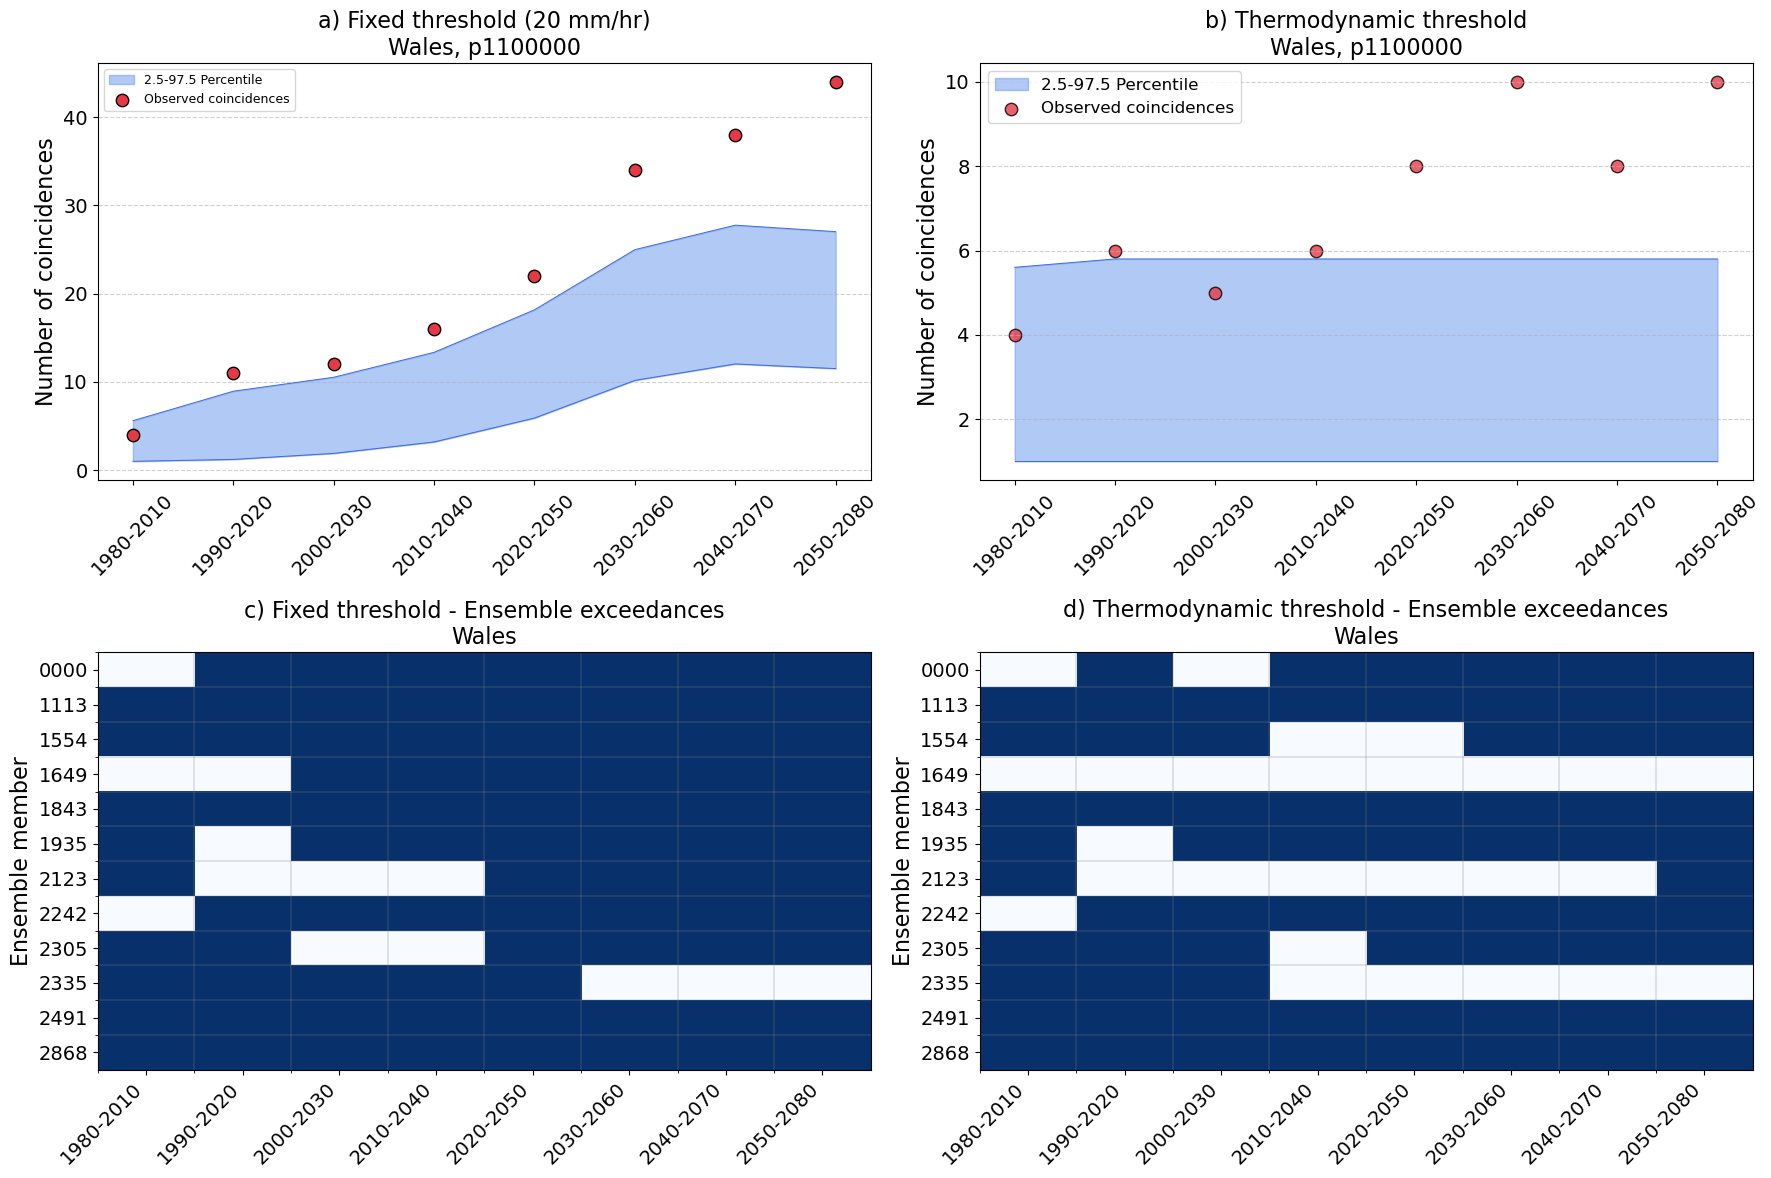

In [ ]:
region_code = 'Wales'  #region code
ensemble = '0000'      #standard member
wet_threshold = 20   #threshold for fixed threshold approach 
lower_month = 6
higher_month = 9
delT = 4
tau = 1
len_wet = 1
meteo_window = 4

period_title = ('1980-2010', '1990-2020', '2000-2030', '2010-2040', '2020-2050', '2030-2060', '2040-2070', '2050-2080')
num_periods = len(period_title)

# 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ============================================================
# SUBPLOT 1 (Top-Left): Fixed therhosld 
# ============================================================
ax1 = axes[0, 0]

cube = iris.load(f'path/to/your/data/p110{ensemble}_{region_code}.nc')[0] #data is the montly ranfall data for the region and ensemble you want to analyse
month_range = iris.Constraint(time=lambda cell: PartialDateTime(month=lower_month) <= cell.point <= PartialDateTime(month=higher_month))
month_extraction_cube = cube.extract(month_range)

climatology = {f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data
    for j, yr in enumerate(period_title)}

wet_timeseries = [flag_wet_events(climatology[key], len_wet, wet_threshold) for key in climatology] # flag wet events for each period using the fixed threshold
wet_timeseries_overflow = [process_timeseries(wet, meteo_window, len_wet) for wet in wet_timeseries]

period_ECA_30y = calculate_ECA_30y(wet_timeseries, wet_timeseries, delT=delT, tau=tau)
N_trig_coin = [eca.get_coincidences[1] for eca in period_ECA_30y]

binom_probs_t = []
# calc binomial probabilities for each period until the cumulative sum reaches basically 1
for period_index in range(num_periods):
    seriesA = wet_timeseries[period_index]
    seriesB = wet_timeseries[period_index]
    binom_probs_t_i = []
    cumsum = 0
    KT = 0
    while cumsum < 1 - 1e-6:
        p = binomial_Kt(seriesA, seriesB, KT, delT=delT, tau=tau)
        binom_probs_t_i.append(p)
        cumsum += p
        KT += 1
    binom_probs_t.append(binom_probs_t_i)   # append the probs for this period to the list of all periods

# calculate the 1st and 99th percentile for each period using the cum probs
percentile_value_01, percentile_value_99, precursor_y = [], [], []
for period_index in range(num_periods):
    x_values = binom_probs_t[period_index]
    y_values = np.arange(1, len(x_values) + 1)
    cumulative_probs = np.cumsum(x_values)
    
    p_99 = np.interp(0.975, cumulative_probs, y_values)
    p_01 = np.interp(0.025, cumulative_probs, y_values)
    
    percentile_value_99.append(p_99)
    percentile_value_01.append(p_01)
    precursor_y.append(N_trig_coin[period_index])

ax1.plot(range(num_periods), percentile_value_01, color='royalblue', lw=0.7)
ax1.plot(range(num_periods), percentile_value_99, color='royalblue', lw=0.7)
ax1.fill_between(range(num_periods), percentile_value_01, percentile_value_99, color='cornflowerblue', alpha=0.5, label='2.5-97.5 Percentile')
ax1.scatter(range(num_periods), precursor_y, label='Observed coincidences', color='#E63946', edgecolor='black', s=80)
ax1.set_xticks(range(num_periods))
ax1.set_xticklabels(period_title, rotation=45)
#ax1.set_xlabel("Time periods", fontsize=11)
ax1.set_ylabel("Number of coincidences", fontsize=16)
ax1.set_title(f'a) Fixed threshold (20 mm/hr)\nWales, p110{ensemble}', fontsize=16)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend(loc='upper left', fontsize=9)

# ============================================================
# SUBPLOT 2 (Top-Right): thermodybamic threhosld
# ============================================================
ax2 = axes[0, 1]

cube = iris.load(f'path/to/your/data/p110{ensemble}_{region_code}.nc')[0] #data is the montly ranfall data for the region and ensemble you want to analyse
month_range = iris.Constraint(time=lambda cell: PartialDateTime(month=lower_month) <= cell.point <= PartialDateTime(month=higher_month))
month_extraction_cube = cube.extract(month_range)

climatology = {f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data
    for j, yr in enumerate(period_title)}

#
percentile_1980_10 = get_percentile(wet_threshold, climatology['cube_1980-2010']) #percentile of 20 mm/hr in the 1980-2010 period
# get the value that corresponds to this percentile in each period to use as a threshold for the thermodynamic approach
values_from_percentiles = {
    'value_from_percentile_1980_10': get_value_from_percentile(percentile_1980_10, climatology['cube_1980-2010']),
    'value_from_percentile_1990_20': get_value_from_percentile(percentile_1980_10, climatology['cube_1990-2020']),
    'value_from_percentile_2000_30': get_value_from_percentile(percentile_1980_10, climatology['cube_2000-2030']),
    'value_from_percentile_2010_40': get_value_from_percentile(percentile_1980_10, climatology['cube_2010-2040']),
    'value_from_percentile_2020_50': get_value_from_percentile(percentile_1980_10, climatology['cube_2020-2050']),
    'value_from_percentile_2030_60': get_value_from_percentile(percentile_1980_10, climatology['cube_2030-2060']),
    'value_from_percentile_2040_70': get_value_from_percentile(percentile_1980_10, climatology['cube_2040-2070']),
    'value_from_percentile_2050_80': get_value_from_percentile(percentile_1980_10, climatology['cube_2050-2080'])}

wet_thresholds = [values_from_percentiles[f'value_from_percentile_{yr.replace("-", "_")}'] 
                  for yr in ['1980_10', '1990_20', '2000_30', '2010_40','2020_50', '2030_60', '2040_70', '2050_80']]

wet_timeseries_therm_adjust = [flag_wet_events(climatology[key], len_wet, wet_threshold)for key, wet_threshold in zip(climatology.keys(), wet_thresholds)]
wet_timeseries_fixed = [flag_wet_events(climatology[key], len_wet, wet_threshold) for key in climatology]

period_ECA_30y = calculate_ECA_30y(wet_timeseries_therm_adjust, wet_timeseries_therm_adjust, delT=delT, tau=tau)
N_trig_coin = [eca.get_coincidences[1] for eca in period_ECA_30y]

binom_probs_t = []
for period_index in range(num_periods):
    seriesA = wet_timeseries_therm_adjust[period_index]
    seriesB = wet_timeseries_therm_adjust[period_index]
    binom_probs_therm_i = []
    cumsum = 0
    KT = 0
    while cumsum < 1 - 1e-6:
        p = binomial_Kt(seriesA, seriesB, KT, delT=delT, tau=tau)
        binom_probs_therm_i.append(p)
        cumsum += p
        KT += 1
    binom_probs_t.append(binom_probs_therm_i)

percentile_value_01, percentile_value_99, precursor_y = [], [], []
for i in range(num_periods):
    x_values = binom_probs_t[i]
    y_values = np.arange(1, len(x_values) + 1)
    cumulative_probs = np.cumsum(x_values)
    
    p_99 = np.interp(0.975, cumulative_probs, y_values)
    p_01 = np.interp(0.025, cumulative_probs, y_values)
    
    percentile_value_99.append(p_99)
    percentile_value_01.append(p_01)
    precursor_y.append(N_trig_coin[i])

ax2.plot(range(num_periods), percentile_value_01, color='royalblue', lw=0.7)
ax2.plot(range(num_periods), percentile_value_99, color='royalblue', lw=0.7)
ax2.fill_between(range(num_periods), percentile_value_01, percentile_value_99, color='cornflowerblue', alpha=0.5, label='2.5-97.5 Percentile')
ax2.scatter(range(num_periods), precursor_y, label='Observed coincidences', color='#E63946', edgecolor='black', marker='o', s=80, alpha=0.8)
ax2.set_xticks(range(num_periods))
ax2.set_xticklabels(period_title, rotation=45)
#ax2.set_xlabel("Time periods", fontsize=11)
ax2.set_ylabel("Number of coincidences", fontsize=16)
ax2.set_title(f'b) Thermodynamic threshold\nWales, p110{ensemble}', fontsize=16)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(loc='upper left', fontsize=12)

# ============================================================
# SUBPLOT 3 (Bottom-Left): Hovmoller type plot, fixed threshold
# ============================================================
ax3 = axes[1, 0]

results_fixed_wales = {ens: [] for ens in ensembles_dict}

for ensemble in ensembles_dict:
    try:
        cube = iris.load(f'path/to/your/data/p110{ensemble}_{region_code}.nc')[0] #data is the montly ranfall data for the region and ensemble you want to analyse
        month_range = iris.Constraint(time=lambda cell: PartialDateTime(month=lower_month) <= cell.point <= PartialDateTime(month=higher_month))
        month_extraction_cube = cube.extract(month_range)
        
        climatology = {
            f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data for j, yr in enumerate(period_title)}
        
        wet_timeseries = [flag_wet_events(climatology[key], len_wet, wet_threshold) for key in climatology]
        period_ECA_30y = calculate_ECA_30y(wet_timeseries, wet_timeseries, delT=delT, tau=tau)
        N_trig_coin = [eca.get_coincidences[1] for eca in period_ECA_30y]
        
        binom_probs_t = []
        for period_index in range(num_periods):
            seriesA = wet_timeseries[period_index]
            seriesB = wet_timeseries[period_index]
            binom_probs_t_i = []
            cumsum = 0
            KT = 0
            while cumsum < 1 - 1e-6:
                p = binomial_Kt(seriesA, seriesB, KT, delT=delT, tau=tau)
                binom_probs_t_i.append(p)
                cumsum += p
                KT += 1
            binom_probs_t.append(binom_probs_t_i)
        
        percentile_value_99 = []
        precursor_y = []
        for period_index in range(num_periods):
            x_values = binom_probs_t[period_index]
            y_values = np.arange(1, len(x_values) + 1)
            cumulative_probs = np.cumsum(x_values)
            p_99 = np.interp(0.975, cumulative_probs, y_values)
            percentile_value_99.append(p_99)
            precursor_y.append(N_trig_coin[period_index])
        
        for period_index in range(num_periods):
            if precursor_y[period_index] > percentile_value_99[period_index]:
                results_fixed_wales[ensemble].append(1)
            else:
                results_fixed_wales[ensemble].append(0)
    except Exception as e:
        print(f"Error processing ensemble {ensemble}: {e}")
        results_fixed_wales[ensemble] = [0] * num_periods

# Create heatmap
heatmap_data_fixed = np.zeros((len(ensembles_dict), num_periods))
for ens_idx, ensemble in enumerate(ensembles_dict):
    for period_idx in range(num_periods):
        if len(results_fixed_wales[ensemble]) > period_idx:
            heatmap_data_fixed[ens_idx, period_idx] = results_fixed_wales[ensemble][period_idx]

im3 = ax3.imshow(heatmap_data_fixed, cmap='Blues', aspect='auto', vmin=0, vmax=1, interpolation='nearest')
ax3.set_xticks(range(num_periods))
ax3.set_xticklabels(period_title, rotation=45, ha='right')
ax3.set_yticks(range(len(ensembles_dict)))
ax3.set_yticklabels(list(ensembles_dict.keys()))
#ax3.set_xlabel('Time period', fontsize=11)
ax3.set_ylabel('Ensemble member', fontsize=16)
ax3.set_title('c) Fixed threshold - Ensemble exceedances\nWales', fontsize=16)
ax3.set_xticks(np.arange(num_periods) - 0.5, minor=True)
ax3.set_yticks(np.arange(len(ensembles_dict)) - 0.5, minor=True)
ax3.grid(which='minor', color='gray', linestyle='-', linewidth=0.3)

# ============================================================
# SUBPLOT 4 (Bottom-Right): hovmoeller type plto - thermo threhodld
# ============================================================
ax4 = axes[1, 1]

results_thermo_wales = {ens: [] for ens in ensembles_dict}

for ensemble in ensembles_dict:
    try:
        cube = iris.load(f'path/to/your/data/p110{ensemble}_{region_code}.nc')[0] #data is the montly ranfall data for the region and ensemble you want to analyse
        month_range = iris.Constraint(time=lambda cell: PartialDateTime(month=lower_month) <= cell.point <= PartialDateTime(month=higher_month))
        month_extraction_cube = cube.extract(month_range)
        
        climatology = {
            f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data
            for j, yr in enumerate(period_title)}
        
        percentile_1980_10 = get_percentile(wet_threshold, climatology['cube_1980-2010']) #get percentile of 20 mm/hr in the 1980-2010 period to use as a reference for the thermodynamic threshold
        values_from_percentiles = {
            'value_from_percentile_1980_10': get_value_from_percentile(percentile_1980_10, climatology['cube_1980-2010']),
            'value_from_percentile_1990_20': get_value_from_percentile(percentile_1980_10, climatology['cube_1990-2020']),
            'value_from_percentile_2000_30': get_value_from_percentile(percentile_1980_10, climatology['cube_2000-2030']),
            'value_from_percentile_2010_40': get_value_from_percentile(percentile_1980_10, climatology['cube_2010-2040']),
            'value_from_percentile_2020_50': get_value_from_percentile(percentile_1980_10, climatology['cube_2020-2050']),
            'value_from_percentile_2030_60': get_value_from_percentile(percentile_1980_10, climatology['cube_2030-2060']),
            'value_from_percentile_2040_70': get_value_from_percentile(percentile_1980_10, climatology['cube_2040-2070']),
            'value_from_percentile_2050_80': get_value_from_percentile(percentile_1980_10, climatology['cube_2050-2080'])}
        
        wet_thresholds = [values_from_percentiles[f'value_from_percentile_{yr.replace("-", "_")}'] 
                          for yr in ['1980_10', '1990_20', '2000_30', '2010_40', '2020_50', '2030_60', '2040_70', '2050_80']]
        
        wet_timeseries_therm_adjust = [flag_wet_events(climatology[key], len_wet, wet_threshold) 
                                        for key, wet_threshold in zip(climatology.keys(), wet_thresholds)]
        
        # Use thermodynamic-adjusted timeseries for ECA calculation (not fixed!)
        period_ECA_30y = calculate_ECA_30y(wet_timeseries_therm_adjust, wet_timeseries_therm_adjust, delT=delT, tau=tau)
        N_trig_coin = [eca.get_coincidences[1] for eca in period_ECA_30y]
        
        binom_probs_t = []
        for period_index in range(num_periods):
            seriesA = wet_timeseries_therm_adjust[period_index]
            seriesB = wet_timeseries_therm_adjust[period_index]
            binom_probs_therm_i = []
            cumsum = 0
            KT = 0
            while cumsum < 1 - 1e-6:
                p = binomial_Kt(seriesA, seriesB, KT, delT=delT, tau=tau)
                binom_probs_therm_i.append(p)
                cumsum += p
                KT += 1
            binom_probs_t.append(binom_probs_therm_i)
        
        percentile_value_99 = []
        precursor_y = []
        for i in range(num_periods):
            x_values = binom_probs_t[i]
            y_values = np.arange(1, len(x_values) + 1)
            cumulative_probs = np.cumsum(x_values)
            p_99 = np.interp(0.975, cumulative_probs, y_values)
            percentile_value_99.append(p_99)
            precursor_y.append(N_trig_coin[i])
        
        for period_index in range(num_periods):
            if precursor_y[period_index] > percentile_value_99[period_index]:
                results_thermo_wales[ensemble].append(1)
            else:
                results_thermo_wales[ensemble].append(0)
    except Exception as e:
        print(f"Error processing ensemble {ensemble}: {e}")
        results_thermo_wales[ensemble] = [0] * num_periods

# Create heatmap
heatmap_data_thermo = np.zeros((len(ensembles_dict), num_periods))
for ens_idx, ensemble in enumerate(ensembles_dict):
    for period_idx in range(num_periods):
        if len(results_thermo_wales[ensemble]) > period_idx:
            heatmap_data_thermo[ens_idx, period_idx] = results_thermo_wales[ensemble][period_idx]

im4 = ax4.imshow(heatmap_data_thermo, cmap='Blues', aspect='auto', vmin=0, vmax=1, interpolation='nearest')
ax4.set_xticks(range(num_periods))
ax4.set_xticklabels(period_title, rotation=45, ha='right')
ax4.set_yticks(range(len(ensembles_dict)))
ax4.set_yticklabels(list(ensembles_dict.keys()))
#ax4.set_xlabel('Time period', fontsize=11)
ax4.set_ylabel('Ensemble member', fontsize=16)
ax4.set_title('d) Thermodynamic threshold - Ensemble exceedances\nWales', fontsize=16)
ax4.set_xticks(np.arange(num_periods) - 0.5, minor=True)
ax4.set_yticks(np.arange(len(ensembles_dict)) - 0.5, minor=True)
ax4.grid(which='minor', color='gray', linestyle='-', linewidth=0.3)

plt.tight_layout()
plt.show()

## 3-panel plot with regional ensemble agreement

In [ ]:
# Parameters
lower_month = 6
higher_month = 9
delT = 4
wet_threshold = 20
tau = 1
len_wet = 1
meteo_window = 4

period_title = ('1980-2010', '1990-2020', '2000-2030', '2010-2040', '2020-2050', '2030-2060', '2040-2070', '2050-2080')
num_periods = len(period_title)

# Initialize results dictionaries
results_fixed = {region_code: {ens: [] for ens in ensembles_dict} for region_code in regions.keys()}
results_thermo = {region_code: {ens: [] for ens in ensembles_dict} for region_code in regions.keys()}

# Loop through all regions and ensembles
for region_code in regions.keys():
    print(f"Processing region: {region_code}")
    
    for ensemble in ensembles_dict:
        try:
            cube = iris.load(f'path/to/your/data/p110{ensemble}_{region_code}.nc')[0] #data is the montly ranfall data for the region and ensemble you want to analyse
            month_range = iris.Constraint(time=lambda cell: PartialDateTime(month=lower_month) <= cell.point <= PartialDateTime(month=higher_month))
            month_extraction_cube = cube.extract(month_range)
            
            climatology = {
                f'cube_{yr}': decompose_years_30y(month_extraction_cube)[j].data
                for j, yr in enumerate(period_title)}
            
            # ===== FIXED THRESHOLD =====
            wet_timeseries_fixed = [flag_wet_events(climatology[key], len_wet, wet_threshold) for key in climatology]
            period_ECA_fixed = calculate_ECA_30y(wet_timeseries_fixed, wet_timeseries_fixed, delT=delT, tau=tau)
            N_trig_fixed = [eca.get_coincidences[1] for eca in period_ECA_fixed]
            
            # Binomial probabilities for fixed threshold
            for period_index in range(num_periods):
                seriesA = wet_timeseries_fixed[period_index]
                binom_probs = []
                cumsum = 0
                KT = 0
                while cumsum < 1 - 1e-6:
                    p = binomial_Kt(seriesA, seriesA, KT, delT=delT, tau=tau)
                    binom_probs.append(p)
                    cumsum += p
                    KT += 1
                
                y_values = np.arange(1, len(binom_probs) + 1)
                cumulative_probs = np.cumsum(binom_probs)
                p_99 = np.interp(0.975, cumulative_probs, y_values)
                
                if N_trig_fixed[period_index] > p_99:
                    results_fixed[region_code][ensemble].append(1)
                else:
                    results_fixed[region_code][ensemble].append(0)
            
            # ===== THERMODYNAMIC THRESHOLD =====
            percentile_1980_10 = get_percentile(wet_threshold, climatology['cube_1980-2010'])
            wet_thresholds = [get_value_from_percentile(percentile_1980_10, climatology[f'cube_{yr}']) 
                              for yr in period_title]
            
            wet_timeseries_thermo = [flag_wet_events(climatology[key], len_wet, wet_threshold) 
                                      for key, wet_threshold in zip(climatology.keys(), wet_thresholds)]
            period_ECA_thermo = calculate_ECA_30y(wet_timeseries_thermo, wet_timeseries_thermo, delT=delT, tau=tau)
            N_trig_thermo = [eca.get_coincidences[1] for eca in period_ECA_thermo]
            
            # Binomial probabilities for thermodynamic threshold
            for period_index in range(num_periods):
                seriesA = wet_timeseries_thermo[period_index]
                binom_probs = []
                cumsum = 0
                KT = 0
                while cumsum < 1 - 1e-6:
                    p = binomial_Kt(seriesA, seriesA, KT, delT=delT, tau=tau)
                    binom_probs.append(p)
                    cumsum += p
                    KT += 1
                
                y_values = np.arange(1, len(binom_probs) + 1)
                cumulative_probs = np.cumsum(binom_probs)
                p_99 = np.interp(0.975, cumulative_probs, y_values)
                
                if N_trig_thermo[period_index] > p_99:
                    results_thermo[region_code][ensemble].append(1)
                else:
                    results_thermo[region_code][ensemble].append(0)
                    
        except Exception as e:
            print(f"  Error processing ensemble {ensemble}: {e}")
            results_fixed[region_code][ensemble] = [0] * num_periods
            results_thermo[region_code][ensemble] = [0] * num_periods

summary_data = {
    'Region': [],
    '1980-2010 Fixed Threshold': [],
    '2050-2080 Fixed Threshold': [],
    '2050-2080 Thermo Threshold': []
}

for region_code, region_name_list in regions.items():
    region_name = region_name_list[0]
    
    # count ensembles exceeding threshold for each period
    count_fixed_1980 = sum(results_fixed[region_code][ens][0] for ens in ensembles_dict)  # index 0 = 1980-2010
    count_fixed_2050 = sum(results_fixed[region_code][ens][7] for ens in ensembles_dict)  # index 7 = 2050-2080
    count_thermo_2050 = sum(results_thermo[region_code][ens][7] for ens in ensembles_dict)  
    
    summary_data['Region'].append(region_name)
    summary_data['1980-2010 Fixed Threshold'].append(count_fixed_1980)
    summary_data['2050-2080 Fixed Threshold'].append(count_fixed_2050)
    summary_data['2050-2080 Thermo Threshold'].append(count_thermo_2050)

summary_df = pd.DataFrame(summary_data)
print(summary_df)

summary_df.to_csv('path/to/save/summary_ECA_results.csv', index=False)

Processing region: East_Midlands
Processing region: East_Scotland
Processing region: East_of_England
Processing region: North_East_England
Processing region: North_Scotland
Processing region: North_West_England
Processing region: Northern_Ireland
Processing region: South_East_England
Processing region: South_West_England
Processing region: Wales
Processing region: West_Midlands
Processing region: West_Scotland
Processing region: Yorkshire_and_Humber
                  Region  1980-2010 Fixed Threshold  \
0          East Midlands                          5   
1          East Scotland                          7   
2        East of England                          6   
3     North East England                          2   
4         North Scotland                          7   
5     North West England                          3   
6       Northern Ireland                          5   
7     South East England                         10   
8     South West England                         10

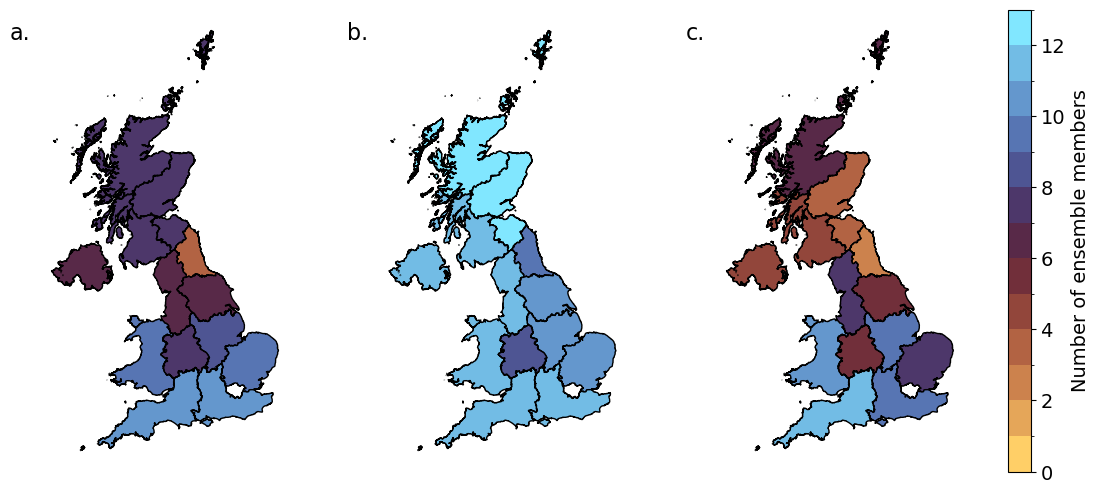

In [ ]:
regions_gdf = gpd.read_file('path/to/your/geoson/regional/mask')

summary_df = pd.read_csv('path/to/your/summary_ECA_results.csv')

#matching region to name
merged = regions_gdf.merge(summary_df, left_on="geo_region", right_on="Region")

# Only keep rows with no missing data in the plotting columns
cols = ['1980-2010 Fixed Threshold', '2050-2080 Fixed Threshold', '2050-2080 Thermo Threshold']
merged_clean = merged.dropna(subset=cols)

#--------------- plot ---------------
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.01, hspace=0)
axes = [fig.add_subplot(gs[0, j]) for j in range(3)]
cols = ['1980-2010 Fixed Threshold', '2050-2080 Fixed Threshold', '2050-2080 Thermo Threshold']
labels = ['a.', 'b.', 'c.']

# discrete colorbar with boundaries for each integer value
boundaries = list(range(0, 14))  # 0, 1, 2, ..., 13
norm = mpl.colors.BoundaryNorm(boundaries, ncolors=256)

for ax, col, label in zip(axes, cols, labels):
    merged_clean.plot(column=col, ax=ax, cmap='managua', edgecolor='black', aspect=1, norm=norm, legend=False)
    ax.axis('off')
    ax.set_aspect('equal')
    # Add label to the left of each plot
    ax.text(-0.08, 0.95, label, transform=ax.transAxes, fontsize=16, va='center', ha='center')

sm = mpl.cm.ScalarMappable(cmap='managua', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.04, spacing='proportional')
cbar.set_label('Number of ensemble members')

plt.show()
